In [1]:
import torch 
import numpy as np
import matplotlib.pyplot as plt 

### Step 1: Sanity check of the training for neural nets

We will first fetch some data from our dataset and use the `encoder_features` and `encoder_labels` net to check if the encoded image of a ring and the encoded labels are close in latent space (we can visualize it in 2d). 

In [2]:
from astro_peek import Encoder

def load_model(paths):
    model_list = []
    for path in tqdm(paths): 
        model_data = torch.load(path, map_location = "cpu")
        cfg = model_data['model_cfg']
        model = Encoder(cfg)
        model.load_state_dict(model_data["model"])
        model_list.append(model)
    return model_list

In [3]:
from glob import glob
from tqdm import tqdm 
from natsort import natsorted

model_path = "/home/noedia/links/scratch/crl/experiments/rings/models/"
encoders_features_dir = "encoder_features/"
encoders_labels_dir = "encoder_labels/"
pattern = "*.pt"

encoder_x_paths = natsorted(glob(model_path + encoders_features_dir + pattern))  
encoder_y_paths = natsorted(glob(model_path + encoders_labels_dir + pattern))

print("Loading the models for different random seeds ")
encoder_x_list = load_model(encoder_x_paths)
encoder_y_list = load_model(encoder_y_paths)

Loading the models for different random seeds 


100%|██████████| 11/11 [00:00<00:00, 540.78it/s]


In [4]:
encoder_x_paths

['/home/noedia/links/scratch/crl/experiments/rings/models/encoder_features/seed_37_latentdim_2.pt',
 '/home/noedia/links/scratch/crl/experiments/rings/models/encoder_features/seed_38_latentdim_2.pt',
 '/home/noedia/links/scratch/crl/experiments/rings/models/encoder_features/seed_39_latentdim_2.pt',
 '/home/noedia/links/scratch/crl/experiments/rings/models/encoder_features/seed_40_latentdim_2.pt',
 '/home/noedia/links/scratch/crl/experiments/rings/models/encoder_features/seed_41_latentdim_2.pt',
 '/home/noedia/links/scratch/crl/experiments/rings/models/encoder_features/seed_42_latentdim_2.pt',
 '/home/noedia/links/scratch/crl/experiments/rings/models/encoder_features/seed_43_latentdim_2.pt',
 '/home/noedia/links/scratch/crl/experiments/rings/models/encoder_features/seed_44_latentdim_2.pt',
 '/home/noedia/links/scratch/crl/experiments/rings/models/encoder_features/seed_45_latentdim_2.pt',
 '/home/noedia/links/scratch/crl/experiments/rings/models/encoder_features/seed_46_latentdim_2.pt',


# Latent space visualization sanity check

(array([  18.,   99.,  522., 1719., 2754., 2641., 1581.,  570.,   86.,
          10.]),
 array([0.0006245 , 0.00070014, 0.00077578, 0.00085142, 0.00092706,
        0.0010027 , 0.00107834, 0.00115398, 0.00122962, 0.00130526,
        0.0013809 ]),
 <BarContainer object of 10 artists>)

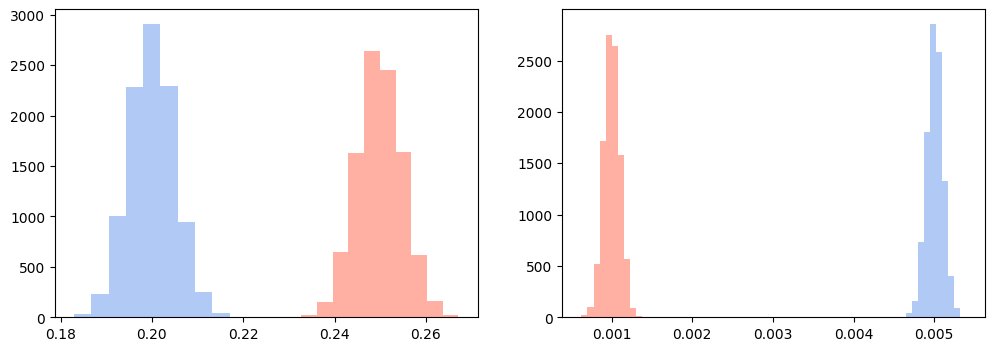

In [5]:
import numpy as np
def sample_prior(prior, size):
    return prior(size)
    
prior_radius_a = lambda size: np.random.normal(loc = 0.2, scale = 0.005, size = size)
prior_radius_b = lambda size: np.random.normal(loc = 0.25, scale = 0.005, size = size)

prior_sigma_a = lambda size: np.random.normal(loc = 5e-3, scale = 1e-4, size = size)
prior_sigma_b = lambda size: np.random.normal(loc = 1e-3, scale = 1e-4, size = size)


fig, axs = plt.subplots(1, 2, figsize = (12, 4))
ax = axs[0]
samples_a = sample_prior(prior_radius_a, size = 10_000)
samples_b = sample_prior(prior_radius_b, size = 10_000)

ax.hist(samples_a, color = "cornflowerblue", alpha  = 0.5)
ax.hist(samples_b, color = "tomato", alpha  = 0.5)


ax = axs[1]
samples_a = sample_prior(prior_sigma_a, size = 10_000)
samples_b = sample_prior(prior_sigma_b, size = 10_000)

ax.hist(samples_a, color = "cornflowerblue", alpha  = 0.5)
ax.hist(samples_b, color = "tomato", alpha  = 0.5)

In [6]:
from datasets import load_from_disk
from tqdm import tqdm
from astro_peek.datasets.make_rings import make_rings

dataset_size = 1000

# Sampling two sets of radius and sigma to see if the model makes a difference between them in latent space.
radius_prior = {"low": 0.1, "high": 0.3}
sigma_prior = {"low": 1e-4, "high": 1e-2}
prior_params_config = {
        "radius": radius_prior, 
        "sigma": sigma_prior
    }

prior_radius_a = lambda size: np.random.normal(loc = 0.25, scale = 0.005, size = size)
prior_radius_b = lambda size: np.random.normal(loc = 0.15, scale = 0.005, size = size)

prior_sigma_a = lambda size: np.random.normal(loc = 5e-3, scale = 1e-4, size = size)
prior_sigma_b = lambda size: np.random.normal(loc = 1e-3, scale = 1e-4, size = size)

# Creating latent factors and normalizing them...
radius = np.concatenate([sample_prior(prior_radius_a, dataset_size), sample_prior(prior_radius_b, dataset_size)])
rng = np.random.default_rng(seed=42)
rng.shuffle(radius)

sigma = np.concatenate([sample_prior(prior_sigma_a, dataset_size), sample_prior(prior_sigma_b, dataset_size)])
rng = np.random.default_rng(seed=42)
rng.shuffle(sigma)

labels = np.concatenate([np.zeros(dataset_size), np.ones(dataset_size)])
rng = np.random.default_rng(seed=42)
rng.shuffle(labels)

theta = np.stack([radius, sigma]).T

# Creating simulations from it 
images = []
img_size = 32
x = np.arange(0, img_size) / img_size
y = np.arange(0, img_size) / img_size
X, Y = np.meshgrid(x,y)
for params in tqdm(theta): 
    image = make_rings(X, Y, radius = params[0], sigma = params[1], center = 0.5)
    images.append(image) 

images = np.array(images)
radius = (radius - radius_prior["low"]) / (radius_prior["high"] - radius_prior["low"])
sigma =  (sigma - sigma_prior["low"]) / (sigma_prior["high"] - sigma_prior["low"])
theta = np.stack([radius, sigma]).T

100%|██████████| 2000/2000 [00:00<00:00, 97996.61it/s]


Checking a few rings 

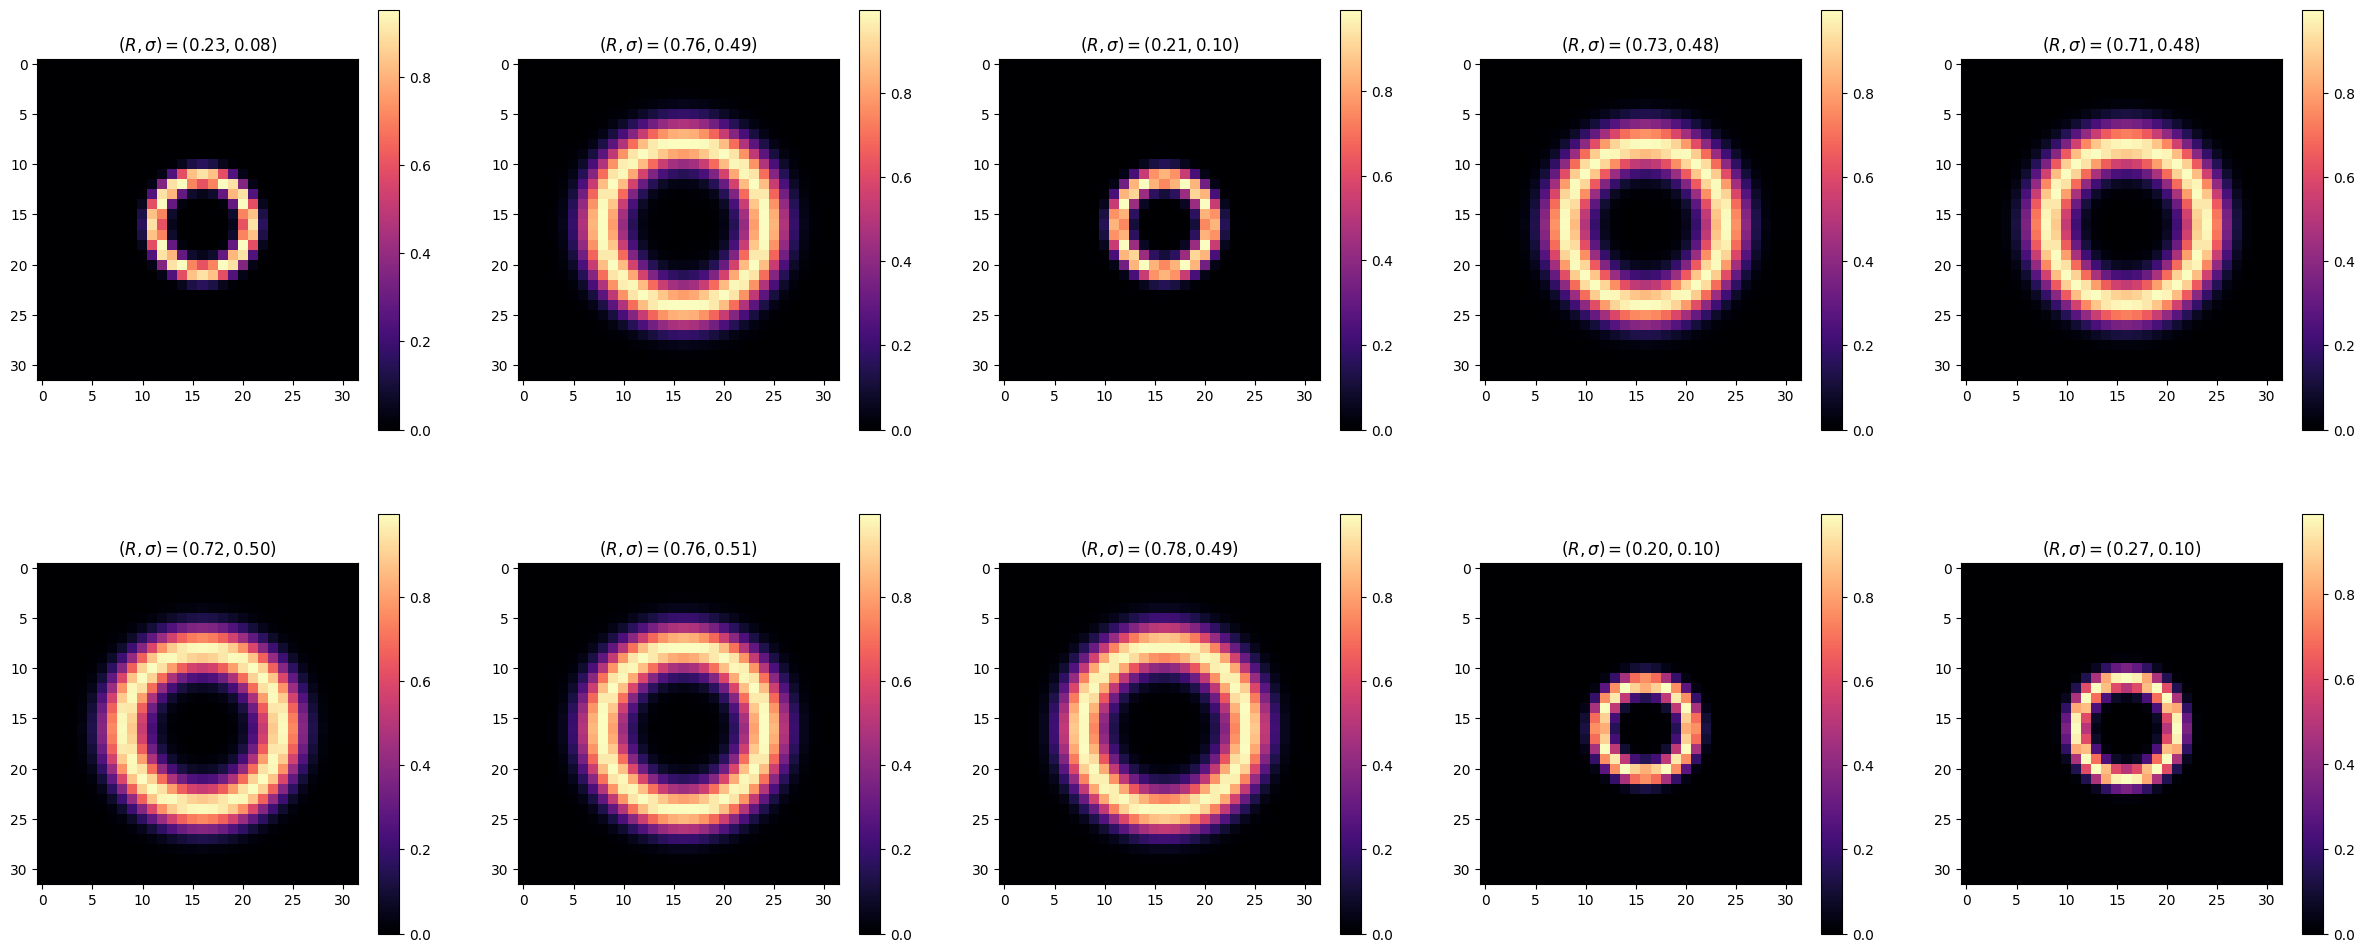

In [7]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(2, 5, figsize = (6 * 5, 6 * 2))

for i, ax in enumerate(axs.flatten()): 
    im = ax.imshow(images[i], cmap = "magma")
    label = theta[i]
    plt.colorbar(im)
    ax.set(title = r"$(R, \sigma) = (%.2f, %.2f)$"%(label[0], label[1]))

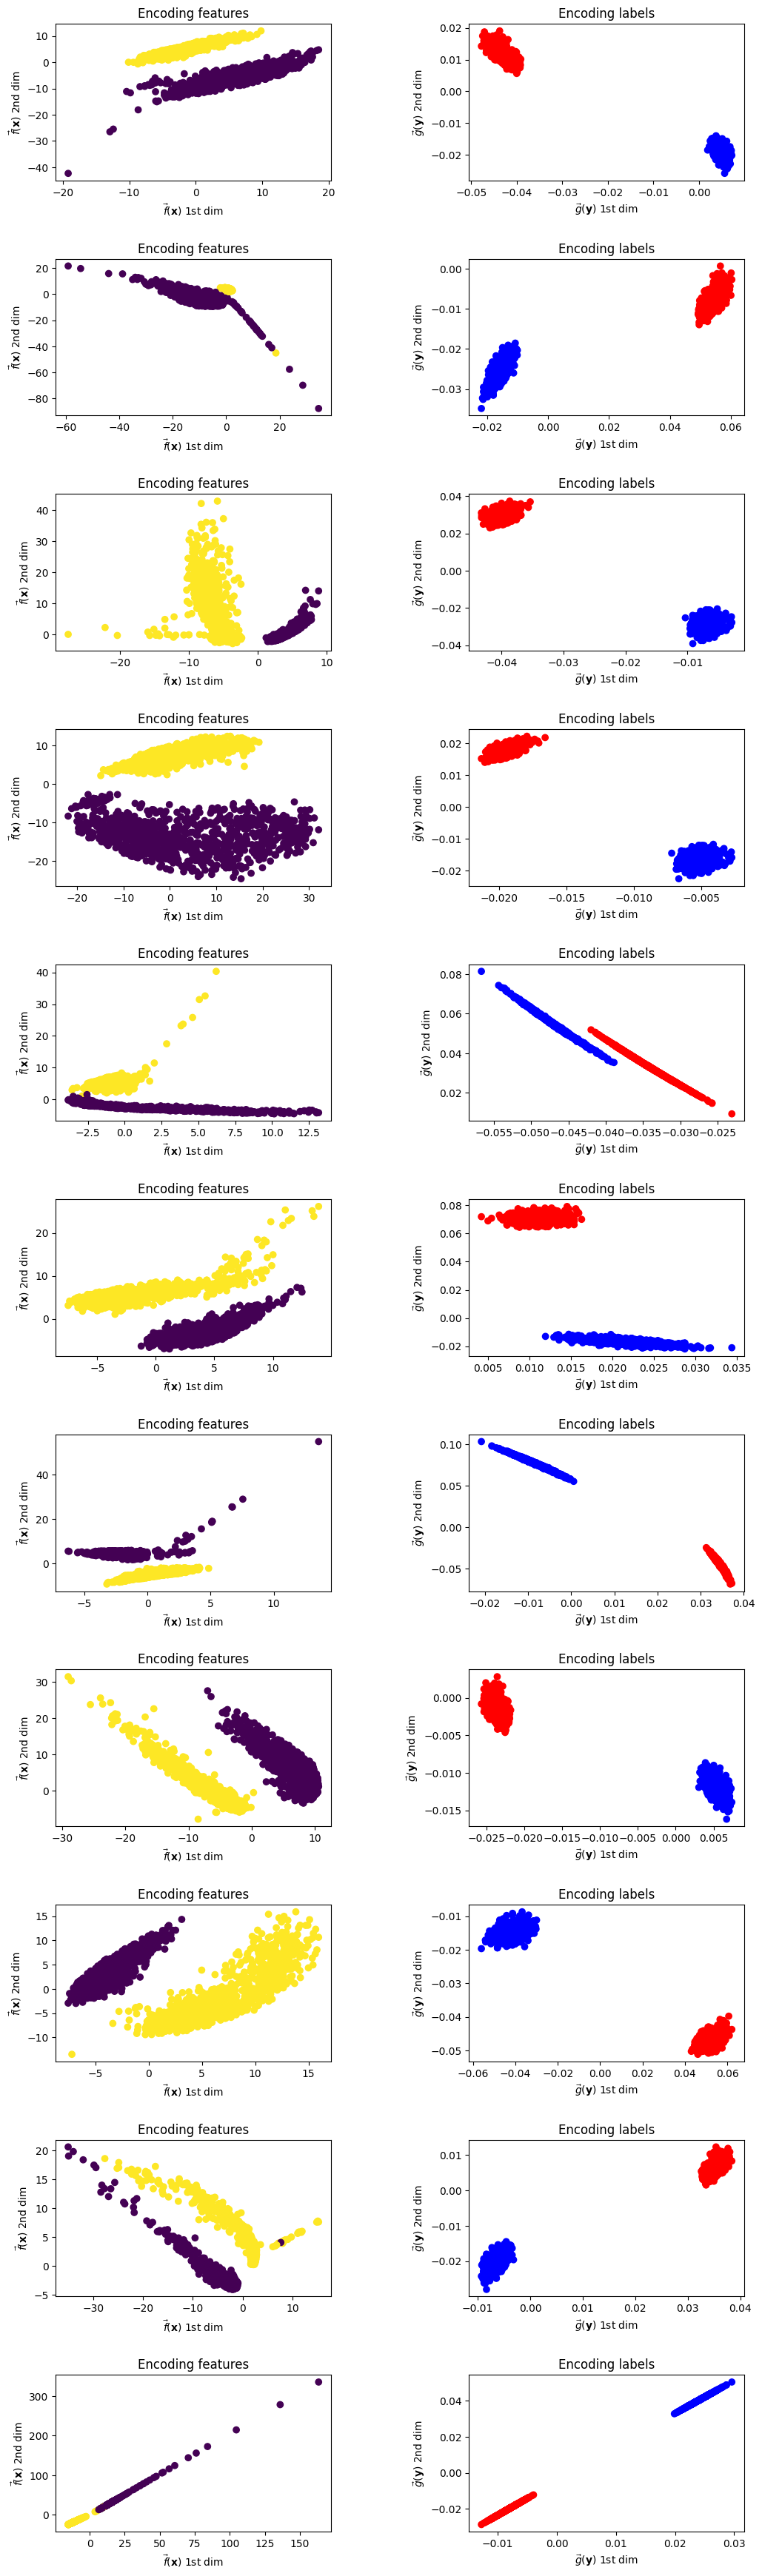

In [8]:
x = images
y = theta


fig, axs = plt.subplots(len(encoder_x_list), 2, figsize = (12, 4 * len(encoder_x_list)))

for i, row_axs in enumerate(axs):
    encoder_x = encoder_x_list[i]
    encoder_y = encoder_y_list[i]
    with torch.no_grad():
        zx = encoder_x(torch.tensor(x).to(torch.float32))
        zy = encoder_y(torch.tensor(y).to(torch.float32))
    ax = row_axs[0]
    
    ax.scatter(*zx.cpu().T, c = labels)
    ax.set(title = "Encoding features", xlabel = r"$\vec{f}(\mathbf{x})$ 1st dim", ylabel = r"$\vec{f}(\mathbf{x})$ 2nd dim")
    ax = row_axs[1]
    ax.scatter(*zy.cpu().T, c = labels, vmin  = 0, vmax = 1, cmap = "bwr")
    ax.set(title = "Encoding labels", xlabel = r"$\vec{g}(\mathbf{y})$ 1st dim", ylabel = r"$\vec{g}(\mathbf{y})$ 2nd dim")


plt.subplots_adjust(wspace = 0.5, hspace = 0.5)

Nice, we observe what we would expect: the two sets of encoded $x$ and $y$ are well separated in latent space. 

## CCA and MCCA
Let's try what Salma did for a single pair of `encoder_features` for now. We will take the 

In [28]:
def plot_CCA_all_latents(dims, scores, models):
    i, j = models[0], models[1]
    plt.figure(figsize=(13,4))
    plt.plot(dims, scores, "o", label="CCA")
    plt.xlabel("Latent dimension")
    plt.ylabel("CCA value")
    plt.title("CCA value vs latent dimension for models "+str(i)+" and "+str(j))
    plt.xticks(dims)
    plt.ylim(0,1.05)
    plt.show()
    
def plot_features(z, latent, models):
    latent_label = latent+1
    i, j = models[0], models[1]
    z1, z2 = z[i-1], z[j-1]
    
    # Plot the view in the shared latent space for the desired latent 
    plt.figure(figsize=(6,3))
    plt.title('Correlation between models '+str(i)+' and '+str(j)+' in shared latent space for latent '+str(latent_label))
    plt.scatter(z1[:,latent], z2[:,latent], marker='.')
    plt.xlabel('Feature '+str(latent_label)+' for model '+str(i))
    plt.ylabel('Feature '+str(latent_label)+' for model '+str(j))
    plt.show()

Let's get two models with very similar likelihood score. 

In [23]:
from datasets import load_from_disk 

dset = load_from_disk("/home/noedia/links/scratch/crl/experiments/rings/data")
dset = dset.with_format("torch")
nsamples = 2_000

x_set_1 = dset["train"][:nsamples]["image"]
x_set_2 = dset["train"][nsamples:2 * nsamples]["image"]

y_set_1 = dset["train"][:nsamples]["theta"]
y_set_2 = dset["train"][nsamples:2 * nsamples]["theta"]


ndims = 2

In [49]:
x_set_2.shape

torch.Size([2000, 32, 32])

In [35]:
from cca_zoo.linear import CCA
encoder_a = encoder_x_list[8]
encoder_b = encoder_x_list[3]

with torch.no_grad():
    model1_samples = encoder_a(x_set_1)
    model2_samples = encoder_b(x_set_1) 

train_views = np.concatenate((np.expand_dims(model1_samples, 0), np.expand_dims(model2_samples, 0)), axis=0)
print(train_views.shape)
dims = np.arange(1,ndims+1)

model = CCA(latent_dimensions=ndims).fit(train_views) 

with torch.no_grad():
    model1_samples = encoder_a(x_set_2)
    model2_samples = encoder_b(x_set_2) 
test_views = np.concatenate((np.expand_dims(model1_samples, 0), np.expand_dims(model2_samples, 0)), axis=0)

# Canonical correlations on the test data, one value per latent dimension 
corrs = np.abs(model.score(test_views)) # Returns the average pairwise correlation between the views
print("CCA canonical correlations:", np.round(corrs, ndims))

(2, 2000, 2)
CCA canonical correlations: [0.91 0.87]


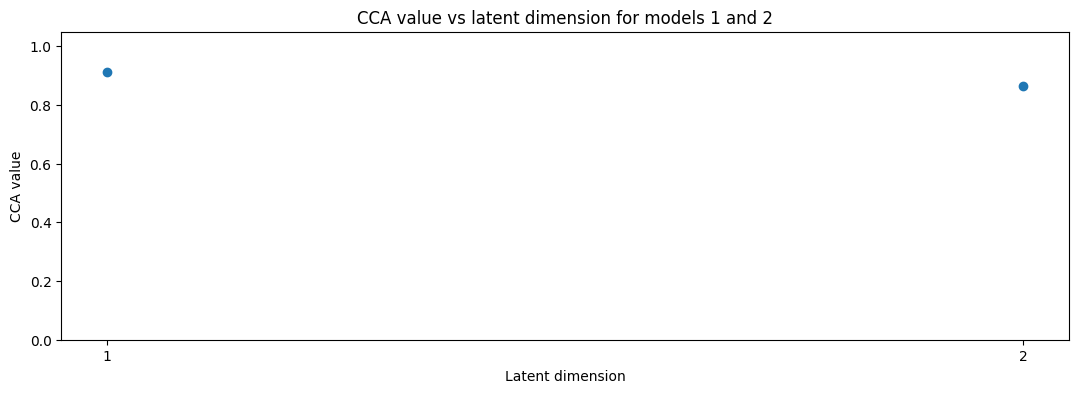

In [36]:
plot_CCA_all_latents(dims, corrs, models=[1,2])

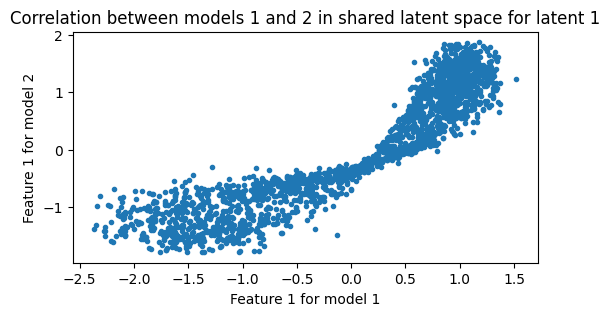

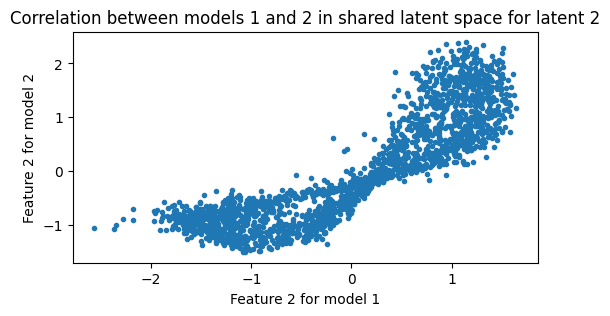

In [37]:
z = model.transform(test_views) 

plot_features(z, 0, models=[1,2])
plot_features(z, 1, models=[1,2])

In [31]:
from cca_zoo.linear import CCA
encoder_a = encoder_y_list[8]
encoder_b = encoder_y_list[3]

with torch.no_grad():
    model1_samples = encoder_a(y_set_1)
    model2_samples = encoder_b(y_set_1) 

train_views = np.concatenate((np.expand_dims(model1_samples, 0), np.expand_dims(model2_samples, 0)), axis=0)
print(train_views.shape)
dims = np.arange(1,ndims+1)

model = CCA(latent_dimensions=ndims).fit(train_views) 

with torch.no_grad():
    model1_samples = encoder_a(y_set_2)
    model2_samples = encoder_b(y_set_2) 
test_views = np.concatenate((np.expand_dims(model1_samples, 0), np.expand_dims(model2_samples, 0)), axis=0)

# Canonical correlations on the test data, one value per latent dimension 
corrs = np.abs(model.score(test_views)) # Returns the average pairwise correlation between the views
print("CCA canonical correlations:", np.round(corrs, ndims))

(2, 2000, 2)
CCA canonical correlations: [1.   0.98]


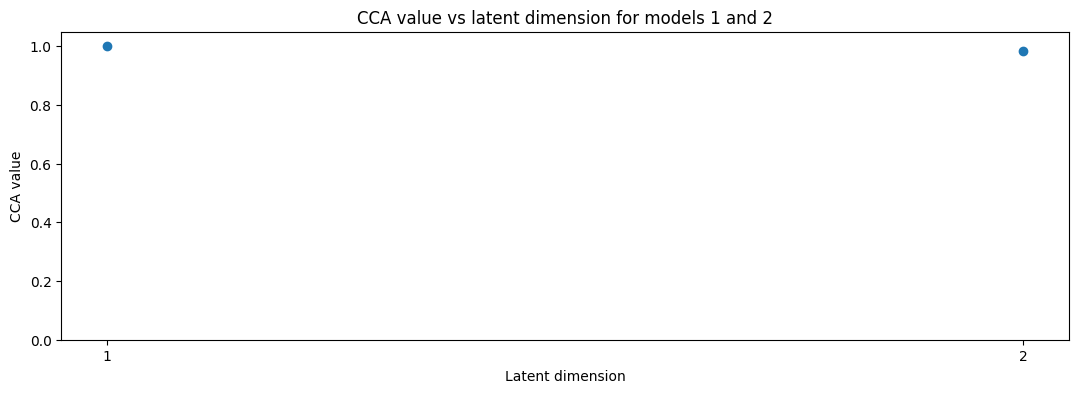

In [32]:
plot_CCA_all_latents(dims, corrs, models=[1,2])

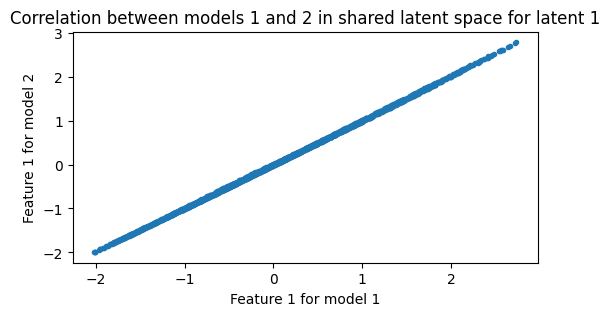

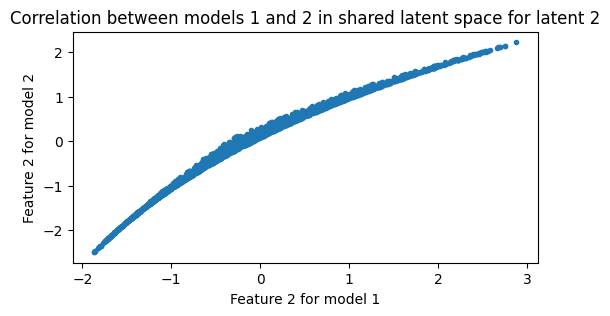

In [34]:
z = model.transform(test_views) 

plot_features(z, 0, models=[1,2])
plot_features(z, 1, models=[1,2])

Fitting a matrix and visualizing the latent space. 

## $R^2$ score

In [17]:


encoder_x_list = []

model_list = []
print("Loading the models for different random seeds ")
for path in tqdm(encoder_x_paths): 
    model_data = torch.load(path, map_location = "cpu")

In [18]:
model_data.keys()

dict_keys(['model', 'model_cfg', 'seed'])

['/home/noedia/links/scratch/crl/experiments/rings/models/encoder_features/seed_47_latentdim_2.pt',
 '/home/noedia/links/scratch/crl/experiments/rings/models/encoder_features/seed_38_latentdim_2.pt',
 '/home/noedia/links/scratch/crl/experiments/rings/models/encoder_features/seed_40_latentdim_2.pt',
 '/home/noedia/links/scratch/crl/experiments/rings/models/encoder_features/seed_42_latentdim_2.pt',
 '/home/noedia/links/scratch/crl/experiments/rings/models/encoder_features/seed_45_latentdim_2.pt',
 '/home/noedia/links/scratch/crl/experiments/rings/models/encoder_features/seed_43_latentdim_2.pt',
 '/home/noedia/links/scratch/crl/experiments/rings/models/encoder_features/seed_44_latentdim_2.pt',
 '/home/noedia/links/scratch/crl/experiments/rings/models/encoder_features/seed_37_latentdim_2.pt',
 '/home/noedia/links/scratch/crl/experiments/rings/models/encoder_features/seed_46_latentdim_2.pt',
 '/home/noedia/links/scratch/crl/experiments/rings/models/encoder_features/seed_39_latentdim_2.pt',


In [12]:
model_path + encoders_features_dir + pattern

'/home/noedia/links/scratch/crl/experiments/rings/models/encoder_features/*.pt'